In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys, os, time, warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
sys.path.insert(0, os.path.abspath('../model'))
sys.path.insert(0, os.path.abspath('../parameter_scan'))

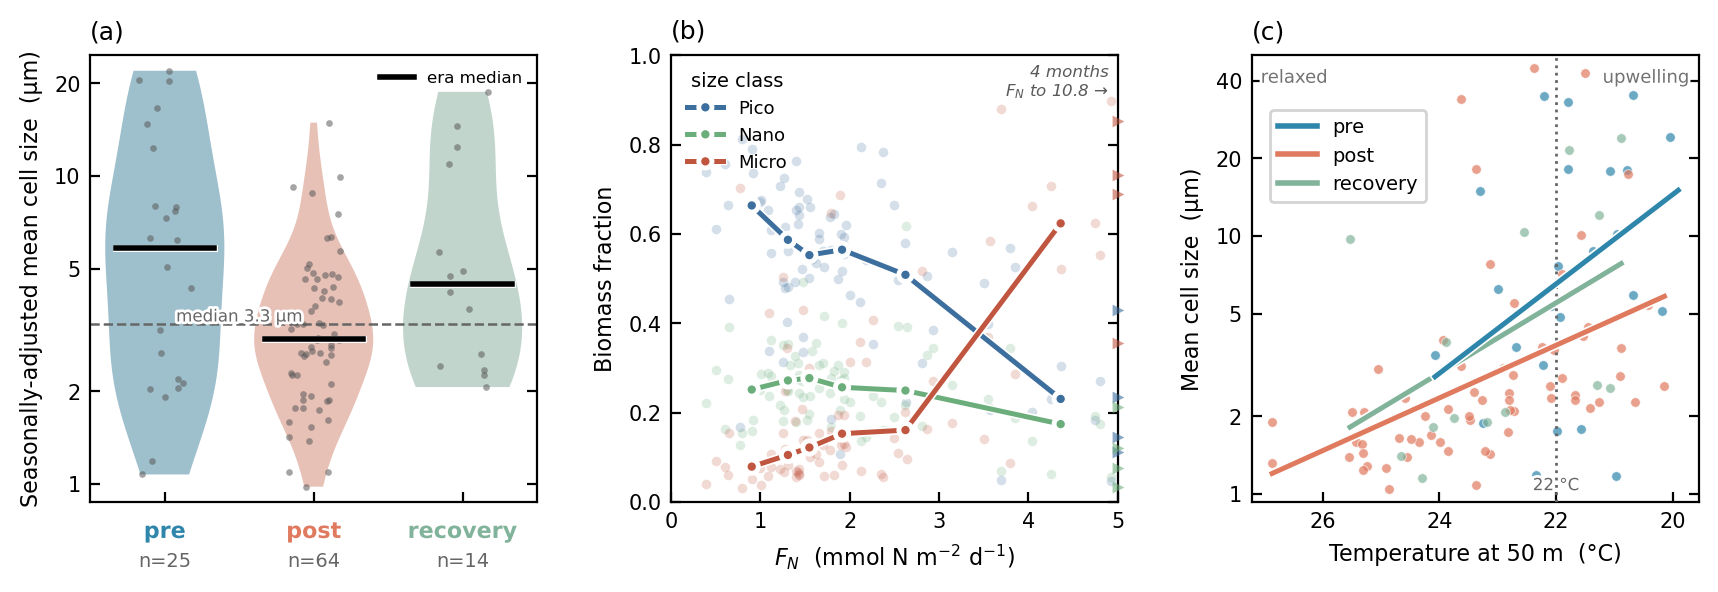

In [21]:
%config InlineBackend.figure_format = 'retina'
# Figure 3 — (a) MCS by era | (b) P/N/M vs F_N | (c) MCS vs temperature
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patheffects as pe
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D
from cariaco_obs import DEFAULT_CSV_PATH

ERA_ORDER = ['pre', 'post', 'recovery']
ERA_COL = {'pre': '#2E86AB', 'post': '#E07A5F', 'recovery': '#81B29A'}
UM_TICKS_A = [1, 2, 5, 10, 20]
UM_TICKS_C = [1, 2, 5, 10, 20, 40]
HALO = [pe.withStroke(linewidth=2.5, foreground='white')]
HALO3 = [pe.withStroke(linewidth=3.0, foreground='white')]
LBL_HALO = [pe.withStroke(linewidth=2, foreground='white')]

df = pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date'])
df['era'] = np.where(df['date'].dt.year < 2005, 'pre',
            np.where(df['date'].dt.year < 2014, 'post', 'recovery'))
df['mcs_log'] = df['size_centroid']
df['mo'] = df['date'].dt.month

fig, (axA, axB, axC) = plt.subplots(1, 3, figsize=(8.6, 3.2))
fig.subplots_adjust(left=0.06, right=0.995, top=0.90, bottom=0.17, wspace=0.30)
for ax in (axA, axB, axC):
    ax.set_box_aspect(1)

# ---------------- (a) MCS era violin, seasonally-adjusted µm ----------------
dA = df.dropna(subset=['mcs_log']).copy()
dA['mcs_anom'] = dA['mcs_log'] - dA.groupby('mo')['mcs_log'].transform('mean')
GM = dA['mcs_log'].mean()
dA['mcs_adj'] = dA['mcs_anom'] + GM
sns.violinplot(data=dA, x='era', y='mcs_adj', order=ERA_ORDER, hue='era',
               palette=ERA_COL, legend=False, inner=None, cut=0, linewidth=0.8, ax=axA)
for v in axA.collections:
    v.set_alpha(0.50); v.set_edgecolor('none')
sns.stripplot(data=dA, x='era', y='mcs_adj', order=ERA_ORDER, color='0.35',
              size=2.4, alpha=0.55, jitter=0.18, ax=axA)
for i, e in enumerate(ERA_ORDER):
    s = dA[dA.era == e]
    axA.plot([i - 0.33, i + 0.33], [s['mcs_adj'].median()] * 2, color='black', lw=2.0,
             zorder=6, path_effects=HALO)
overall_med = dA['mcs_adj'].median()
axA.axhline(overall_med, color='0.4', ls='--', lw=0.9, zorder=1)
axA.text(0.5, overall_med, f'median {10 ** overall_med:.1f} µm', ha='center', va='bottom',
         fontsize=6, color='0.4', path_effects=LBL_HALO, zorder=7)
axA.set_xlim(-0.5, 2.5)
axA.set_ylim(dA['mcs_adj'].min() - 0.05, dA['mcs_adj'].max() + 0.05)
axA.set_yticks([np.log10(u) for u in UM_TICKS_A]); axA.set_yticklabels(UM_TICKS_A)
axA.set_ylabel('Seasonally-adjusted mean cell size  (µm)', fontsize=8)
axA.set_xlabel(''); axA.set_title('(a)', loc='left', fontsize=9)
axA.tick_params(top=False, right=True, direction='in', labelsize=7.5)
axA.set_xticks(range(3)); axA.set_xticklabels([])
for i, e in enumerate(ERA_ORDER):
    axA.text(i, -0.04, e, transform=axA.get_xaxis_transform(), ha='center', va='top',
             fontsize=8, color=ERA_COL[e], fontweight='bold', clip_on=False, path_effects=LBL_HALO)
    axA.text(i, -0.11, f'n={len(dA[dA.era == e])}', transform=axA.get_xaxis_transform(),
             ha='center', va='top', fontsize=7, color='0.4', clip_on=False)
axA.legend(handles=[Line2D([0], [0], color='black', lw=2, label='era median')],
           loc='upper right', frameon=False, fontsize=6)

# ---------------- (b) P/N/M fraction vs F_N ----------------
FNCOL, XCUT = 'FN_mmolN_m2_d', 5.0
BINS = [('Pico', 'pico_mmolN', '#3C6E9E'),
        ('Nano', 'nano_mmolN', '#6BAE7B'),
        ('Micro', 'micro_mmolN', '#C0563F')]
binc = [c for _, c, _ in BINS]
dB = df.dropna(subset=binc + [FNCOL]).copy()
tot = dB[binc].sum(axis=1)
for name, c, _ in BINS:
    dB[name + '_frac'] = dB[c] / tot
dB['fn_bin'] = pd.qcut(dB[FNCOL], 6, duplicates='drop')
centers = dB.groupby('fn_bin', observed=True)[FNCOL].median()
inb, oob = dB[dB[FNCOL] <= XCUT], dB[dB[FNCOL] > XCUT]
for name, c, col in BINS:
    axB.scatter(inb[FNCOL], inb[name + '_frac'], s=12, color=col, alpha=0.22, lw=0, zorder=2)
    axB.scatter(np.full(len(oob), XCUT), oob[name + '_frac'], marker='>', s=18,
                color=col, alpha=0.6, lw=0, zorder=6, clip_on=False)
    med = dB.groupby('fn_bin', observed=True)[name + '_frac'].median()
    axB.plot(centers.values, med.values, color=col, lw=1.8, marker='o', ms=3.5,
             mec='white', mew=0.5, zorder=5, path_effects=HALO3, label=name)
axB.set_xlim(0, XCUT); axB.set_ylim(0, 1)
axB.xaxis.set_major_locator(MaxNLocator(nbins=5))
axB.tick_params(top=False, right=True, direction='in', labelsize=7.5)
axB.set_xlabel('$F_N$  (mmol N m$^{-2}$ d$^{-1}$)', fontsize=8)
axB.set_ylabel('Biomass fraction', fontsize=8)
axB.set_title('(b)', loc='left', fontsize=9)
axB.text(0.98, 0.98, f'{len(oob)} months\n$F_N$ to {dB[FNCOL].max():.1f} →',
         transform=axB.transAxes, ha='right', va='top', fontsize=6, color='0.35', style='italic')
axB.legend(title='size class', frameon=False, fontsize=6.5, title_fontsize=7, loc='upper left')

# ---------------- (c) MCS vs temperature at 50 m ----------------
XCOL, XTHRESH = 'temp_50m', 22.0
dC = df.dropna(subset=['mcs_log', XCOL]).copy()
zmap = {'pre': 7, 'post': 6, 'recovery': 5}
for e in ERA_ORDER:
    s = dC[dC.era == e]
    axC.scatter(s[XCOL], s['mcs_log'], s=12, color=ERA_COL[e], alpha=0.7,
                edgecolor='white', linewidth=0.3, zorder=3)
    if len(s) >= 8:
        b = np.polyfit(s[XCOL], s['mcs_log'], 1)
        xx = np.linspace(s[XCOL].min(), s[XCOL].max(), 50)
        axC.plot(xx, np.polyval(b, xx), color=ERA_COL[e], lw=1.8, zorder=zmap[e], path_effects=HALO3)
axC.axvline(XTHRESH, color='0.4', ls=':', lw=1.0, zorder=4)
axC.invert_xaxis()
axC.set_ylim(dC['mcs_log'].min() - 0.05, dC['mcs_log'].max() + 0.05)
axC.set_yticks([np.log10(u) for u in UM_TICKS_C]); axC.set_yticklabels(UM_TICKS_C)
axC.xaxis.set_major_locator(MaxNLocator(nbins=5))
axC.set_ylabel('Mean cell size  (µm)', fontsize=8)
axC.set_xlabel('Temperature at 50 m  (°C)', fontsize=8)
axC.set_title('(c)', loc='left', fontsize=9)
axC.tick_params(top=False, right=True, direction='in', labelsize=7.5)
axC.text(XTHRESH, 0.02, '22 °C', transform=axC.get_xaxis_transform(), ha='center', va='bottom',
         fontsize=6, color='0.4', path_effects=LBL_HALO)
axC.text(0.02, 0.97, 'relaxed', transform=axC.transAxes, ha='left', va='top',
         fontsize=6.5, color='0.45', path_effects=LBL_HALO)
axC.text(0.98, 0.97, 'upwelling', transform=axC.transAxes, ha='right', va='top',
         fontsize=6.5, color='0.45', path_effects=LBL_HALO)
axC.legend(handles=[Line2D([0], [0], color=ERA_COL[e], lw=2, label=e) for e in ERA_ORDER],
           loc='upper left', bbox_to_anchor=(0.02, 0.90), frameon=True, framealpha=0.85,
           edgecolor='0.8', fontsize=7)

# fig.savefig('figure3.pdf', bbox_inches='tight')   # uncomment to export
plt.show()

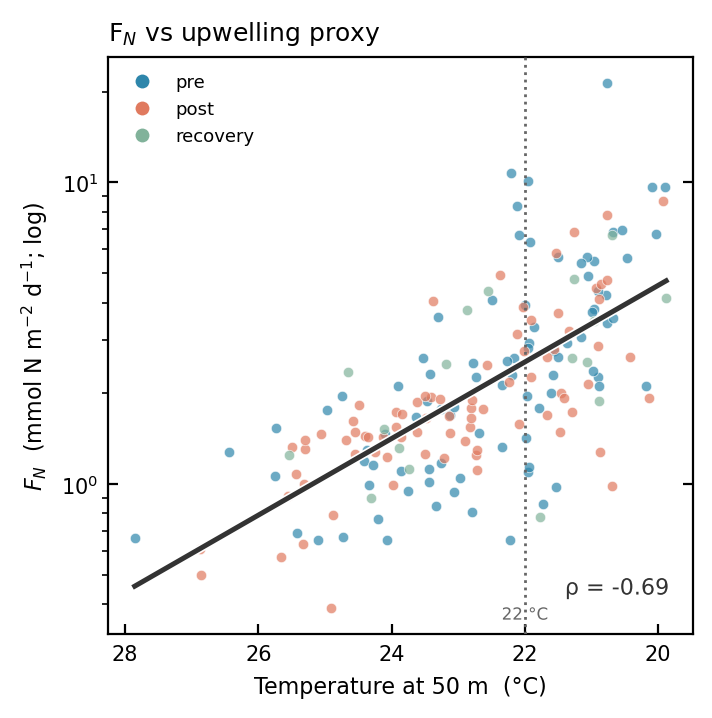

group        n  rho(F_N,temp50)         p
all        185           -0.695   5.5e-28
pre         88           -0.697   4.8e-14
post        80           -0.716   8.4e-14
recovery    17           -0.623    0.0076


In [22]:
%config InlineBackend.figure_format = 'retina'
# Fig 3 add-on — F_N vs temp_50m: coupling between the obs upwelling proxy and the model forcing.
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D
from scipy.stats import spearmanr
from cariaco_obs import DEFAULT_CSV_PATH

ERA_ORDER = ['pre', 'post', 'recovery']
ERA_COL = {'pre': '#2E86AB', 'post': '#E07A5F', 'recovery': '#81B29A'}
HALO = [pe.withStroke(linewidth=3.0, foreground='white')]
LBL_HALO = [pe.withStroke(linewidth=2, foreground='white')]
XCOL, XTHRESH, FNCOL = 'temp_50m', 22.0, 'FN_mmolN_m2_d'

df = pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date'])
df['era'] = np.where(df['date'].dt.year < 2005, 'pre',
            np.where(df['date'].dt.year < 2014, 'post', 'recovery'))
d = df.dropna(subset=[FNCOL, XCOL]).copy()

fig, ax = plt.subplots(figsize=(3.7, 3.7))
fig.subplots_adjust(left=0.17, right=0.96, top=0.93, bottom=0.15)
for e in ERA_ORDER:
    s = d[d.era == e]
    ax.scatter(s[XCOL], s[FNCOL], s=14, color=ERA_COL[e], alpha=0.7,
               edgecolor='white', linewidth=0.3, zorder=3)
b = np.polyfit(d[XCOL], np.log10(d[FNCOL]), 1)          # overall trend, fit in log-F_N
xx = np.linspace(d[XCOL].min(), d[XCOL].max(), 50)
ax.plot(xx, 10 ** np.polyval(b, xx), color='0.2', lw=1.8, zorder=5, path_effects=HALO)

ax.axvline(XTHRESH, color='0.4', ls=':', lw=1.0, zorder=4)
ax.set_yscale('log'); ax.invert_xaxis()
ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
ax.tick_params(top=False, right=True, direction='in', labelsize=7.5)
ax.set_xlabel('Temperature at 50 m  (°C)', fontsize=8)
ax.set_ylabel('$F_N$  (mmol N m$^{-2}$ d$^{-1}$; log)', fontsize=8)
ax.set_title('F$_N$ vs upwelling proxy', loc='left', fontsize=9)
ax.text(XTHRESH, 0.02, '22 °C', transform=ax.get_xaxis_transform(), ha='center', va='bottom',
        fontsize=6, color='0.4', path_effects=LBL_HALO)

rho, p = spearmanr(d[XCOL], d[FNCOL])
ax.text(0.96, 0.06, f'ρ = {rho:+.2f}', transform=ax.transAxes, ha='right', va='bottom',
        fontsize=8, color='0.2', path_effects=LBL_HALO)
ax.legend(handles=[Line2D([0], [0], marker='o', color='w', markerfacecolor=ERA_COL[e],
          markersize=6, label=e) for e in ERA_ORDER], loc='upper left', frameon=False, fontsize=6.5)
plt.show()

print(f"{'group':9s} {'n':>4s} {'rho(F_N,temp50)':>16s} {'p':>9s}")
for e in ['all'] + ERA_ORDER:
    s = d if e == 'all' else d[d.era == e]
    r, pp = spearmanr(s[XCOL], s[FNCOL])
    print(f"{e:9s} {len(s):>4d} {r:>16.3f} {pp:>9.2g}")

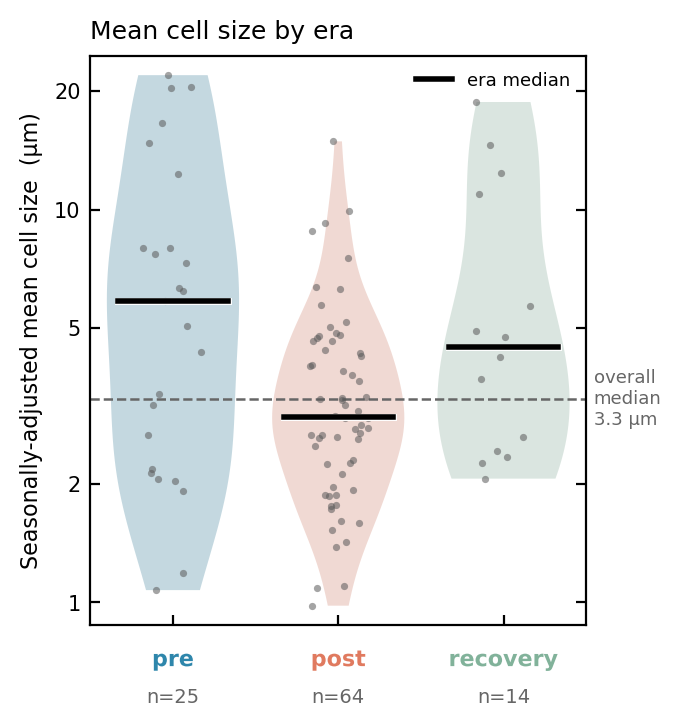

In [12]:
%config InlineBackend.figure_format = 'retina'
# Fig 3 Panel 1 — MCS era violin (seasonally-adjusted µm).
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
from cariaco_obs import DEFAULT_CSV_PATH

ERA_ORDER = ['pre', 'post', 'recovery']
ERA_COL = {'pre': '#2E86AB', 'post': '#E07A5F', 'recovery': '#81B29A'}
UM_TICKS = [1, 2, 5, 10, 20]
HALO = [pe.withStroke(linewidth=2.5, foreground='white')]
LBL_HALO = [pe.withStroke(linewidth=2, foreground='white')]

df = pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date'])
df['era'] = np.where(df['date'].dt.year < 2005, 'pre',
            np.where(df['date'].dt.year < 2014, 'post', 'recovery'))
d = df.dropna(subset=['size_centroid']).copy()
d['mo'] = d['date'].dt.month
d['mcs_anom'] = d['size_centroid'] - d.groupby('mo')['size_centroid'].transform('mean')
GM = d['size_centroid'].mean()
d['mcs_adj'] = d['mcs_anom'] + GM

fig, ax = plt.subplots(figsize=(3.7, 3.7))
fig.subplots_adjust(left=0.17, right=0.84, top=0.93, bottom=0.16)
sns.violinplot(data=d, x='era', y='mcs_adj', order=ERA_ORDER, hue='era',
               palette=ERA_COL, legend=False, inner=None, cut=0, linewidth=0.8, ax=ax)
for v in ax.collections:
    v.set_alpha(0.30); v.set_edgecolor('none')
sns.stripplot(data=d, x='era', y='mcs_adj', order=ERA_ORDER, color='0.35',
              size=2.6, alpha=0.55, jitter=0.18, ax=ax)
for i, e in enumerate(ERA_ORDER):
    s = d[d.era == e]
    ax.plot([i - 0.33, i + 0.33], [s['mcs_adj'].median()] * 2, color='black', lw=2.0,
            zorder=6, path_effects=HALO)

overall_med = d['mcs_adj'].median()
ax.axhline(overall_med, color='0.4', ls='--', lw=0.9, zorder=1)
ax.text(1.015, overall_med, f'overall\nmedian\n{10 ** overall_med:.1f} µm', transform=ax.get_yaxis_transform(),
        va='center', ha='left', fontsize=6.5, color='0.4')

ax.set_xlim(-0.5, 2.5)
ax.set_ylim(d['mcs_adj'].min() - 0.05, d['mcs_adj'].max() + 0.05)
ax.set_yticks([np.log10(u) for u in UM_TICKS]); ax.set_yticklabels(UM_TICKS)
ax.set_ylabel('Seasonally-adjusted mean cell size  (µm)', fontsize=8)
ax.set_xlabel('')
ax.set_title('Mean cell size by era', loc='left', fontsize=9)
ax.tick_params(top=False, right=True, direction='in', labelsize=7.5)

# era names as Fig-1-styled x labels (ticks kept), n beneath
ax.set_xticks(range(3)); ax.set_xticklabels([])
for i, e in enumerate(ERA_ORDER):
    ax.text(i, -0.04, e, transform=ax.get_xaxis_transform(), ha='center', va='top',
            fontsize=8, color=ERA_COL[e], fontweight='bold', clip_on=False, path_effects=LBL_HALO)
    ax.text(i, -0.11, f'n={len(d[d.era == e])}', transform=ax.get_xaxis_transform(),
            ha='center', va='top', fontsize=7, color='0.4', clip_on=False)

ax.legend(handles=[Line2D([0], [0], color='black', lw=2, label='era median')],
          loc='upper right', frameon=False, fontsize=6.5)
plt.show()

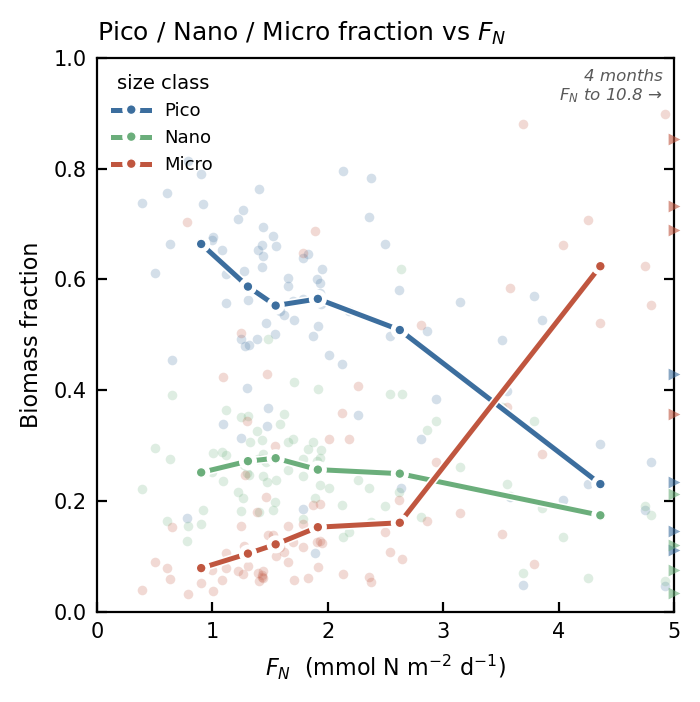

off-scale (F_N>5.0): n=4; median P/N/M = 0.19/0.10/0.71


In [5]:
%config InlineBackend.figure_format = 'retina'
# Fig 3 Panel 2 — Pico/Nano/Micro biomass fraction vs F_N (linear, view cut at 5; off-scale flagged).
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.ticker import MaxNLocator
from cariaco_obs import DEFAULT_CSV_PATH

HALO = [pe.withStroke(linewidth=3.0, foreground='white')]
FNCOL = 'FN_mmolN_m2_d'
XCUT = 5.0
BINS = [('Pico', 'pico_mmolN', '#3C6E9E'),
        ('Nano', 'nano_mmolN', '#6BAE7B'),
        ('Micro', 'micro_mmolN', '#C0563F')]
cols = [c for _, c, _ in BINS]

df = pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date'])
d = df.dropna(subset=cols + [FNCOL]).copy()
tot = d[cols].sum(axis=1)
for name, c, _ in BINS:
    d[name + '_frac'] = d[c] / tot
d['fn_bin'] = pd.qcut(d[FNCOL], 6, duplicates='drop')
centers = d.groupby('fn_bin', observed=True)[FNCOL].median()
meds = {name: d.groupby('fn_bin', observed=True)[name + '_frac'].median() for name, _, _ in BINS}

inb, oob = d[d[FNCOL] <= XCUT], d[d[FNCOL] > XCUT]

fig, ax = plt.subplots(figsize=(3.7, 3.6))
fig.subplots_adjust(left=0.16, right=0.94, top=0.92, bottom=0.15)
for name, c, col in BINS:
    ax.scatter(inb[FNCOL], inb[name + '_frac'], s=12, color=col, alpha=0.22, lw=0, zorder=2)
    ax.scatter(np.full(len(oob), XCUT), oob[name + '_frac'], marker='>', s=18,
               color=col, alpha=0.6, lw=0, zorder=6, clip_on=False)          # off-scale flag
    ax.plot(centers.values, meds[name].values, color=col, lw=1.8, marker='o', ms=3.5,
            mec='white', mew=0.5, zorder=5, path_effects=HALO, label=name)

ax.set_xlim(0, XCUT); ax.set_ylim(0, 1)
ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
ax.tick_params(top=False, right=True, direction='in', labelsize=7.5)
ax.set_xlabel('$F_N$  (mmol N m$^{-2}$ d$^{-1}$)', fontsize=8)
ax.set_ylabel('Biomass fraction', fontsize=8)
ax.set_title('Pico / Nano / Micro fraction vs $F_N$', loc='left', fontsize=9)
ax.text(0.98, 0.98, f'{len(oob)} months\n$F_N$ to {d[FNCOL].max():.1f} →',
        transform=ax.transAxes, ha='right', va='top', fontsize=6, color='0.35', style='italic')
ax.legend(title='size class', frameon=False, fontsize=6.5, title_fontsize=7, loc='upper left')
plt.show()

print(f"off-scale (F_N>{XCUT}): n={len(oob)}; median P/N/M = "
      f"{oob['Pico_frac'].median():.2f}/{oob['Nano_frac'].median():.2f}/{oob['Micro_frac'].median():.2f}")

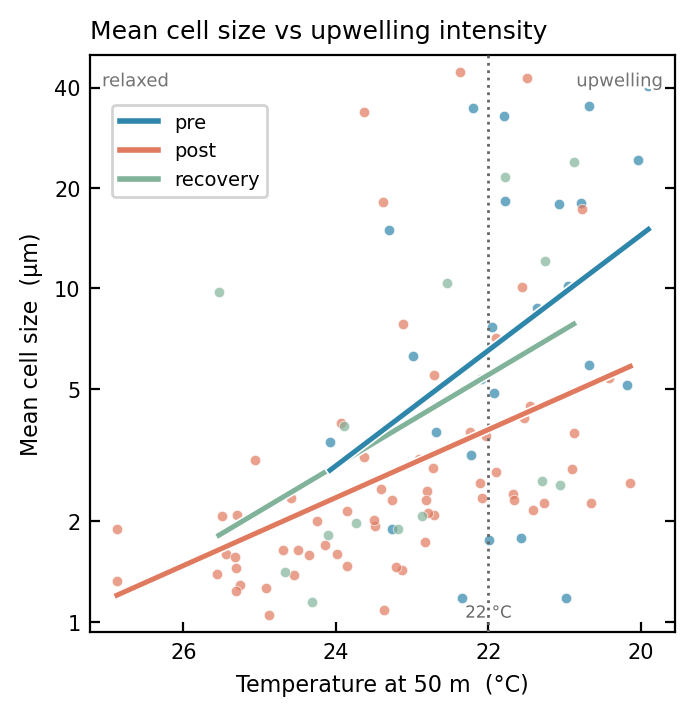

era          n  slope(log µm/°C)     rho         p
all        103           -0.1405  -0.589   5.8e-11
pre         25           -0.1732  -0.425     0.034
post        64           -0.1020  -0.648   7.1e-09
recovery    14           -0.1362  -0.618     0.019


In [17]:
%config InlineBackend.figure_format = 'retina'
# Fig 3 Panel 3 — Mean cell size vs temperature at 50 m, by era. x inverted so upwelling (cold) is on the right.
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.ticker import MaxNLocator
from scipy.stats import spearmanr
from cariaco_obs import DEFAULT_CSV_PATH

ERA_ORDER = ['pre', 'post', 'recovery']
ERA_COL = {'pre': '#2E86AB', 'post': '#E07A5F', 'recovery': '#81B29A'}
UM_TICKS = [1, 2, 5, 10, 20, 40]
HALO = [pe.withStroke(linewidth=3.0, foreground='white')]
LBL_HALO = [pe.withStroke(linewidth=2, foreground='white')]
XCOL, XTHRESH = 'temp_50m', 22.0

df = pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date'])
df['era'] = np.where(df['date'].dt.year < 2005, 'pre',
            np.where(df['date'].dt.year < 2014, 'post', 'recovery'))
df['mcs_log'] = df['size_centroid']                    # log10 MCS (µm)
d = df.dropna(subset=['mcs_log', XCOL]).copy()

fig, ax = plt.subplots(figsize=(3.7, 3.7))
fig.subplots_adjust(left=0.17, right=0.96, top=0.93, bottom=0.15)
for e in ERA_ORDER:
    s = d[d.era == e]
    ax.scatter(s[XCOL], s['mcs_log'], s=14, color=ERA_COL[e], alpha=0.7,
               edgecolor='white', linewidth=0.3, zorder=3)
    if len(s) >= 8:
        b = np.polyfit(s[XCOL], s['mcs_log'], 1)
        xx = np.linspace(s[XCOL].min(), s[XCOL].max(), 50)
        ax.plot(xx, np.polyval(b, xx), color=ERA_COL[e], lw=1.8,
                zorder={'pre': 7, 'post': 6, 'recovery': 5}[e], path_effects=HALO)

ax.axvline(XTHRESH, color='0.4', ls=':', lw=1.0, zorder=4)
ax.invert_xaxis()                                      # upwelling (cold) -> right

ax.set_ylim(d['mcs_log'].min() - 0.05, d['mcs_log'].max() + 0.05)
ax.set_yticks([np.log10(u) for u in UM_TICKS]); ax.set_yticklabels(UM_TICKS)
ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
ax.set_ylabel('Mean cell size  (µm)', fontsize=8)
ax.set_xlabel('Temperature at 50 m  (°C)', fontsize=8)
ax.set_title('Mean cell size vs upwelling intensity', loc='left', fontsize=9)
ax.tick_params(top=False, right=True, direction='in', labelsize=7.5)

ax.text(XTHRESH, 0.02, '22 °C', transform=ax.get_xaxis_transform(), ha='center', va='bottom',
        fontsize=6, color='0.4', path_effects=LBL_HALO)
ax.text(0.02, 0.97, 'relaxed', transform=ax.transAxes, ha='left', va='top',
        fontsize=6.5, color='0.45', path_effects=LBL_HALO)
ax.text(0.98, 0.97, 'upwelling', transform=ax.transAxes, ha='right', va='top',
        fontsize=6.5, color='0.45', path_effects=LBL_HALO)

# era legend (identifies the regression lines), top-left
ax.legend(handles=[Line2D([0], [0], color=ERA_COL[e], lw=2, label=e) for e in ERA_ORDER],
          loc='upper left', bbox_to_anchor=(0.02, 0.93), frameon=True, framealpha=0.85,
          edgecolor='0.8', fontsize=7)
plt.show()

print(f"{'era':9s} {'n':>4s} {'slope(log µm/°C)':>17s} {'rho':>7s} {'p':>9s}")
for e in ['all', 'pre', 'post', 'recovery']:
    s = d if e == 'all' else d[d.era == e]
    rho, p = spearmanr(s[XCOL], s['mcs_log'])
    b = np.polyfit(s[XCOL], s['mcs_log'], 1)
    print(f"{e:9s} {len(s):>4d} {b[0]:>17.4f} {rho:>7.3f} {p:>9.2g}")

In [18]:
# Panel 3 backing stats — ANCOVA: does era shift MCS at matched forcing, for temp AND F_N?
import numpy as np, pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
from cariaco_obs import DEFAULT_CSV_PATH

df = pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date'])
df['era'] = np.where(df['date'].dt.year < 2005, 'pre',
            np.where(df['date'].dt.year < 2014, 'post', 'recovery'))
df['mcs_log'] = df['size_centroid']        # log10 MCS (µm)

def run_ancova(forcing, label):
    d = df.dropna(subset=['mcs_log', forcing]).copy()
    print(f"\n================  MCS vs {label}  (n={len(d)})  ================")

    # 1) additive ANCOVA (parallel slopes) — era term = level-shift at matched forcing
    add = smf.ols(f'mcs_log ~ {forcing} + C(era, Treatment(reference="post"))', data=d).fit()
    aov = sm.stats.anova_lm(add, typ=2)
    print("\nAdditive model  mcs_log ~ forcing + era:")
    print(aov.round(4))
    era_row = [r for r in aov.index if 'era' in r][0]
    print(f"  -> era level-shift: F={aov.loc[era_row, 'F']:.2f}  p={aov.loc[era_row, 'PR(>F)']:.3g}")
    print("  adjusted era offsets vs post (at matched forcing):")
    for name, coef in add.params.items():
        if 'C(era' in name:
            who = name.split('[T.')[1].rstrip(']')
            print(f"    {who:9s} {coef:+.3f} log10 µm = {10 ** coef:.2f}x   (p={add.pvalues[name]:.3g})")

    # 2) interaction model — do the slopes differ by era?
    inter = smf.ols(f'mcs_log ~ {forcing} * C(era, Treatment(reference="post"))', data=d).fit()
    aovi = sm.stats.anova_lm(inter, typ=2)
    ix = [r for r in aovi.index if ':' in r][0]
    print(f"\nInteraction (slope difference): F={aovi.loc[ix, 'F']:.2f}  p={aovi.loc[ix, 'PR(>F)']:.3g}"
          f"   (n.s. => parallel slopes; clean level-shift)")

    # 3) annual-mean robustness (independence cross-check)
    ann = (d.assign(yr=d.date.dt.year)
             .groupby('yr').agg(mcs_log=('mcs_log', 'mean'), f=(forcing, 'mean')).reset_index())
    ann['era'] = np.where(ann.yr < 2005, 'pre', np.where(ann.yr < 2014, 'post', 'recovery'))
    add_a = smf.ols('mcs_log ~ f + C(era, Treatment(reference="post"))', data=ann).fit()
    aov_a = sm.stats.anova_lm(add_a, typ=2)
    er = [r for r in aov_a.index if 'era' in r][0]
    print(f"\nAnnual-mean robustness (n_years={len(ann)}): era F={aov_a.loc[er, 'F']:.2f}  "
          f"p={aov_a.loc[er, 'PR(>F)']:.3g}")

for forcing, label in [('temp_50m', 'temperature at 50 m'), ('FN_mmolN_m2_d', 'F_N')]:
    run_ancova(forcing, label)

print("\nNote: OLS SEs assume independent months, but months are autocorrelated -> these p's are "
      "optimistic; the annual-mean ANCOVA is the independence check. era term = vertical offset at "
      "matched forcing (top-down candidate); interaction = whether slopes genuinely differ.")


================  MCS vs temperature at 50 m  (n=103)  ================

Additive model  mcs_log ~ forcing + era:
                                      sum_sq    df        F  PR(>F)
C(era, Treatment(reference="post"))   0.8950   2.0   3.2625  0.0424
temp_50m                              2.9051   1.0  21.1791  0.0000
Residual                             13.5797  99.0      NaN     NaN
  -> era level-shift: F=3.26  p=0.0424
  adjusted era offsets vs post (at matched forcing):
    pre       +0.237 log10 µm = 1.73x   (p=0.0147)
    recovery  +0.128 log10 µm = 1.34x   (p=0.246)

Interaction (slope difference): F=0.48  p=0.62   (n.s. => parallel slopes; clean level-shift)

Annual-mean robustness (n_years=15): era F=3.55  p=0.0646

================  MCS vs F_N  (n=94)  ================

Additive model  mcs_log ~ forcing + era:
                                     sum_sq    df        F  PR(>F)
C(era, Treatment(reference="post"))  0.2132   2.0   1.0896  0.3408
FN_mmolN_m2_d                     

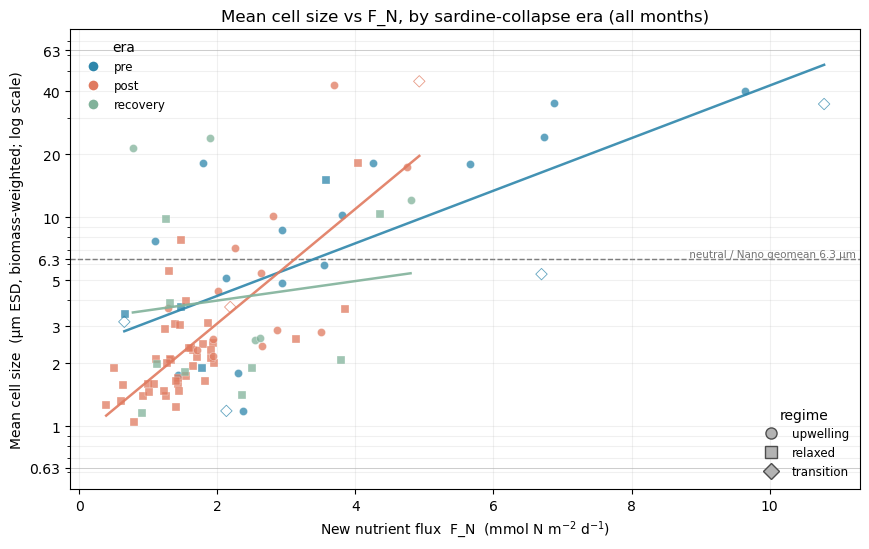

era          n   OLS slope  intercept     rho         p
(slope = log10 µm per unit F_N; Spearman rho is scale-invariant)
all         94      0.1620     0.1859   0.574   1.5e-09
pre         23      0.1258     0.3718   0.712   0.00014
post        57      0.2741    -0.0566   0.707   7.9e-10
recovery    14      0.0466     0.5076   0.160      0.58


In [2]:
# Fig 3 pre-step — Mean cell size (MCS, µm) vs F_N, by sardine-collapse era.
# F_N analogue of the existing temp_50m era panel. All months; regime by marker.
# Run from code/ so cariaco_obs resolves.
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import spearmanr
from cariaco_obs import DEFAULT_CSV_PATH

PICO_UM, NANO_UM, MICRO_UM = 0.63, 6.3, 63.0     # Sieburth bin geomeans
NEUTRAL_UM = NANO_UM                              # uniform composition = 6.3 µm (=10^0.80)
FNCOL = 'FN_mmolN_m2_d'

df = pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date'])
df['mcs_um'] = 10.0 ** df['size_centroid']       # mean cell size, µm
df['era'] = np.where(df['date'].dt.year < 2005, 'pre',
            np.where(df['date'].dt.year < 2014, 'post', 'recovery'))
d = df.dropna(subset=['mcs_um', FNCOL]).copy()
if 'regime_adjusted' in d.columns:
    d['regime_adjusted'] = d['regime_adjusted'].fillna('unknown')
else:
    d['regime_adjusted'] = 'unknown'

era_order = ['pre', 'post', 'recovery']
ecol = {'pre': '#2E86AB', 'post': '#E07A5F', 'recovery': '#81B29A'}
reg_mk = {'upwelling': 'o', 'relaxed': 's', 'transition': 'D'}

fig, ax = plt.subplots(figsize=(8.8, 5.6))
for e in era_order:
    s = d[d.era == e]
    for r, sr in s.groupby('regime_adjusted'):
        m = reg_mk.get(r, 'x')
        face = 'none' if r == 'transition' else ecol[e]
        edge = ecol[e] if r == 'transition' else 'white'
        ax.scatter(sr[FNCOL], sr.mcs_um, marker=m, s=34, alpha=0.75, facecolor=face,
                   edgecolor=edge, linewidth=0.6 if r == 'transition' else 0.3, zorder=3)
    if len(s) >= 8:                                # per-era OLS in log10(MCS) space
        b = np.polyfit(s[FNCOL], np.log10(s.mcs_um), 1)
        xx = np.linspace(s[FNCOL].min(), s[FNCOL].max(), 50)
        ax.plot(xx, 10.0 ** np.polyval(b, xx), color=ecol[e], lw=1.8, alpha=0.9, zorder=4)

ax.axhline(NEUTRAL_UM, color='0.45', ls='--', lw=1, zorder=1)
ax.text(0.995, NEUTRAL_UM, ' neutral / Nano geomean 6.3 µm', transform=ax.get_yaxis_transform(),
        ha='right', va='bottom', fontsize=7.5, color='0.45')
for y in (PICO_UM, MICRO_UM):
    ax.axhline(y, color='0.8', lw=0.6, zorder=1)

ax.set_yscale('log')
um_ticks = [0.63, 1, 2, 3, 5, 6.3, 10, 20, 40, 63]
ax.set_yticks(um_ticks); ax.set_yticklabels([str(t) for t in um_ticks])
ax.set_ylabel('Mean cell size  (µm ESD, biomass-weighted; log scale)')
ax.set_xlabel('New nutrient flux  F_N  (mmol N m$^{-2}$ d$^{-1}$)')
ax.set_title('Mean cell size vs F_N, by sardine-collapse era (all months)')

eh = [Line2D([0], [0], marker='o', color='w', markerfacecolor=ecol[e], markersize=8, label=e)
      for e in era_order]
rh = [Line2D([0], [0], marker=m, color='0.3', markerfacecolor='0.7', linestyle='',
      markersize=8, label=r) for r, m in reg_mk.items()]
leg1 = ax.legend(handles=eh, title='era', loc='upper left', frameon=False, fontsize=8.5)
ax.add_artist(leg1)
ax.legend(handles=rh, title='regime', loc='lower right', frameon=False, fontsize=8.5)
ax.grid(alpha=0.18, which='both')
plt.tight_layout(); plt.show()

print(f"{'era':9s} {'n':>4s} {'OLS slope':>11s} {'intercept':>10s} {'rho':>7s} {'p':>9s}")
print("(slope = log10 µm per unit F_N; Spearman rho is scale-invariant)")
for e in ['all'] + era_order:
    s = d if e == 'all' else d[d.era == e]
    rho, p = spearmanr(s[FNCOL], s.mcs_um)
    b = np.polyfit(s[FNCOL], np.log10(s.mcs_um), 1)
    print(f"{e:9s} {len(s):>4d} {b[0]:>11.4f} {b[1]:>10.4f} {rho:>7.3f} {p:>9.2g}")

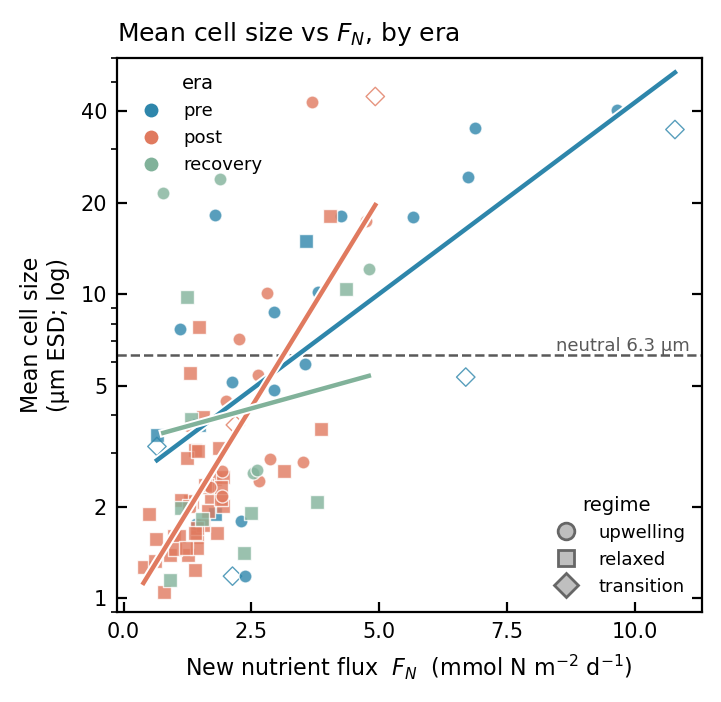

era          n  OLSslope   intcpt     rho         p
all         94    0.1620   0.1859   0.574   1.5e-09
pre         23    0.1258   0.3718   0.712   0.00014
post        57    0.2741  -0.0566   0.707   7.9e-10
recovery    14    0.0466   0.5076   0.160      0.58


In [4]:
%config InlineBackend.figure_format = 'retina'
# Fig 3 pre-step (Fig-1 styling) — Mean cell size (MCS, µm) vs F_N by era.
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D
from scipy.stats import spearmanr
from cariaco_obs import DEFAULT_CSV_PATH

ERA_COL = {'pre': '#2E86AB', 'post': '#E07A5F', 'recovery': '#81B29A'}
REG_MK  = {'upwelling': 'o', 'relaxed': 's', 'transition': 'D'}
UM_TICKS = [1, 2, 5, 10, 20, 40]
HALO = [pe.withStroke(linewidth=3.0, foreground='white')]
PICO_UM, NANO_UM, MICRO_UM = 0.63, 6.3, 63.0      # Sieburth geomeans; neutral = 6.3 µm
FNCOL = 'FN_mmolN_m2_d'

df = pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date'])
df['mcs_um'] = 10.0 ** df['size_centroid']
df['era'] = np.where(df['date'].dt.year < 2005, 'pre',
            np.where(df['date'].dt.year < 2014, 'post', 'recovery'))
d = df.dropna(subset=['mcs_um', FNCOL]).copy()
d['regime_adjusted'] = (d['regime_adjusted'].fillna('unknown')
                        if 'regime_adjusted' in d else 'unknown')

fig, ax = plt.subplots(figsize=(3.7, 3.6))
fig.subplots_adjust(left=0.17, right=0.96, top=0.92, bottom=0.15)
for e in ['pre', 'post', 'recovery']:
    s = d[d.era == e]
    for r, sr in s.groupby('regime_adjusted'):
        m = REG_MK.get(r, 'x')
        face = 'none' if r == 'transition' else ERA_COL[e]
        edge = ERA_COL[e] if r == 'transition' else 'white'
        ax.scatter(sr[FNCOL], sr.mcs_um, marker=m, s=22, alpha=0.8,
                   facecolor=face, edgecolor=edge, linewidth=0.5, zorder=3)
    if len(s) >= 8:
        b = np.polyfit(s[FNCOL], np.log10(s.mcs_um), 1)
        xx = np.linspace(s[FNCOL].min(), s[FNCOL].max(), 50)
        ax.plot(xx, 10.0 ** np.polyval(b, xx), color=ERA_COL[e], lw=1.6,
                zorder=5, path_effects=HALO)

ax.axhline(NANO_UM, color='0.35', ls='--', lw=0.9, zorder=2)
ax.text(0.99, NANO_UM, 'neutral 6.3 µm ', transform=ax.get_yaxis_transform(),
        ha='right', va='bottom', fontsize=6.5, color='0.35')
for y in (PICO_UM, MICRO_UM):
    ax.axhline(y, color='0.82', lw=0.6, zorder=1)

ax.set_yscale('log'); ax.set_yticks(UM_TICKS); ax.set_yticklabels(UM_TICKS)
ax.set_ylim(0.9, 60)
ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
ax.tick_params(top=False, right=True, direction='in', labelsize=7.5)
ax.set_ylabel('Mean cell size\n(µm ESD; log)', fontsize=8)
ax.set_xlabel('New nutrient flux  $F_N$  (mmol N m$^{-2}$ d$^{-1}$)', fontsize=8)
ax.set_title('Mean cell size vs $F_N$, by era', loc='left', fontsize=9)

eh = [Line2D([0], [0], marker='o', color='w', markerfacecolor=ERA_COL[e],
      markersize=6, label=e) for e in ['pre', 'post', 'recovery']]
rh = [Line2D([0], [0], marker=m, color='0.4', markerfacecolor='0.75', linestyle='',
      markersize=6, label=r) for r, m in REG_MK.items()]
leg1 = ax.legend(handles=eh, title='era', loc='upper left', frameon=False,
                 fontsize=6.5, title_fontsize=7)
ax.add_artist(leg1)
ax.legend(handles=rh, title='regime', loc='lower right', frameon=False,
          fontsize=6.5, title_fontsize=7)
plt.show()

print(f"{'era':9s} {'n':>4s} {'OLSslope':>9s} {'intcpt':>8s} {'rho':>7s} {'p':>9s}")
for e in ['all', 'pre', 'post', 'recovery']:
    s = d if e == 'all' else d[d.era == e]
    rho, p = spearmanr(s[FNCOL], s.mcs_um)
    b = np.polyfit(s[FNCOL], np.log10(s.mcs_um), 1)
    print(f"{e:9s} {len(s):>4d} {b[0]:>9.4f} {b[1]:>8.4f} {rho:>7.3f} {p:>9.2g}")

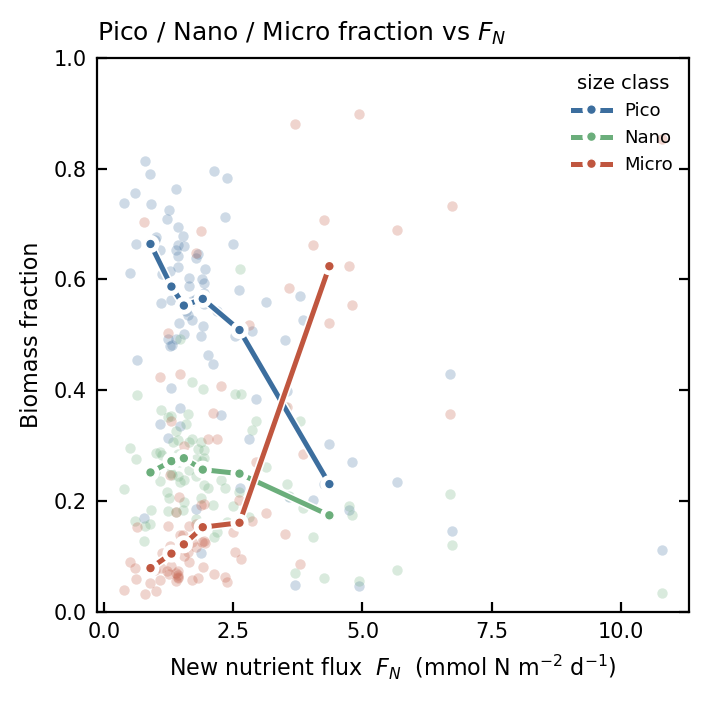

                Pico_frac  Nano_frac  Micro_frac
fn_bin                                          
(0.388, 1.172]      0.664      0.252       0.079
(1.172, 1.429]      0.587      0.272       0.105
(1.429, 1.745]      0.553      0.278       0.122
(1.745, 2.13]       0.565      0.257       0.153
(2.13, 3.527]       0.509      0.250       0.161
(3.527, 10.79]      0.231      0.175       0.624


In [5]:
%config InlineBackend.figure_format = 'retina'
# Companion (Fig-1 styling) — P/N/M biomass fraction vs F_N. Panel 2 design still open.
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.ticker import MaxNLocator
from cariaco_obs import DEFAULT_CSV_PATH

HALO = [pe.withStroke(linewidth=3.0, foreground='white')]
FNCOL = 'FN_mmolN_m2_d'
BINS = [('Pico', 'pico_mmolN', '#3C6E9E'),
        ('Nano', 'nano_mmolN', '#6BAE7B'),
        ('Micro', 'micro_mmolN', '#C0563F')]
cols = [c for _, c, _ in BINS]

df = pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date'])
d = df.dropna(subset=cols + [FNCOL]).copy()
tot = d[cols].sum(axis=1)
for name, c, _ in BINS:
    d[name + '_frac'] = d[c] / tot
d['fn_bin'] = pd.qcut(d[FNCOL], 6, duplicates='drop')
centers = d.groupby('fn_bin', observed=True)[FNCOL].median()

fig, ax = plt.subplots(figsize=(3.7, 3.6))
fig.subplots_adjust(left=0.16, right=0.96, top=0.92, bottom=0.15)
for name, c, col in BINS:
    ax.scatter(d[FNCOL], d[name + '_frac'], s=14, color=col, alpha=0.25, lw=0, zorder=2)
    med = d.groupby('fn_bin', observed=True)[name + '_frac'].median()
    ax.plot(centers.values, med.values, color=col, lw=1.8, marker='o', ms=3.5,
            mec='white', mew=0.5, zorder=5, path_effects=HALO, label=name)

ax.set_ylim(0, 1)
ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
ax.tick_params(top=False, right=True, direction='in', labelsize=7.5)
ax.set_ylabel('Biomass fraction', fontsize=8)
ax.set_xlabel('New nutrient flux  $F_N$  (mmol N m$^{-2}$ d$^{-1}$)', fontsize=8)
ax.set_title('Pico / Nano / Micro fraction vs $F_N$', loc='left', fontsize=9)
ax.legend(title='size class', frameon=False, fontsize=6.5, title_fontsize=7, loc='upper right')
plt.show()

print(d.groupby('fn_bin', observed=True)[[b[0] + '_frac' for b in BINS]].median().round(3))

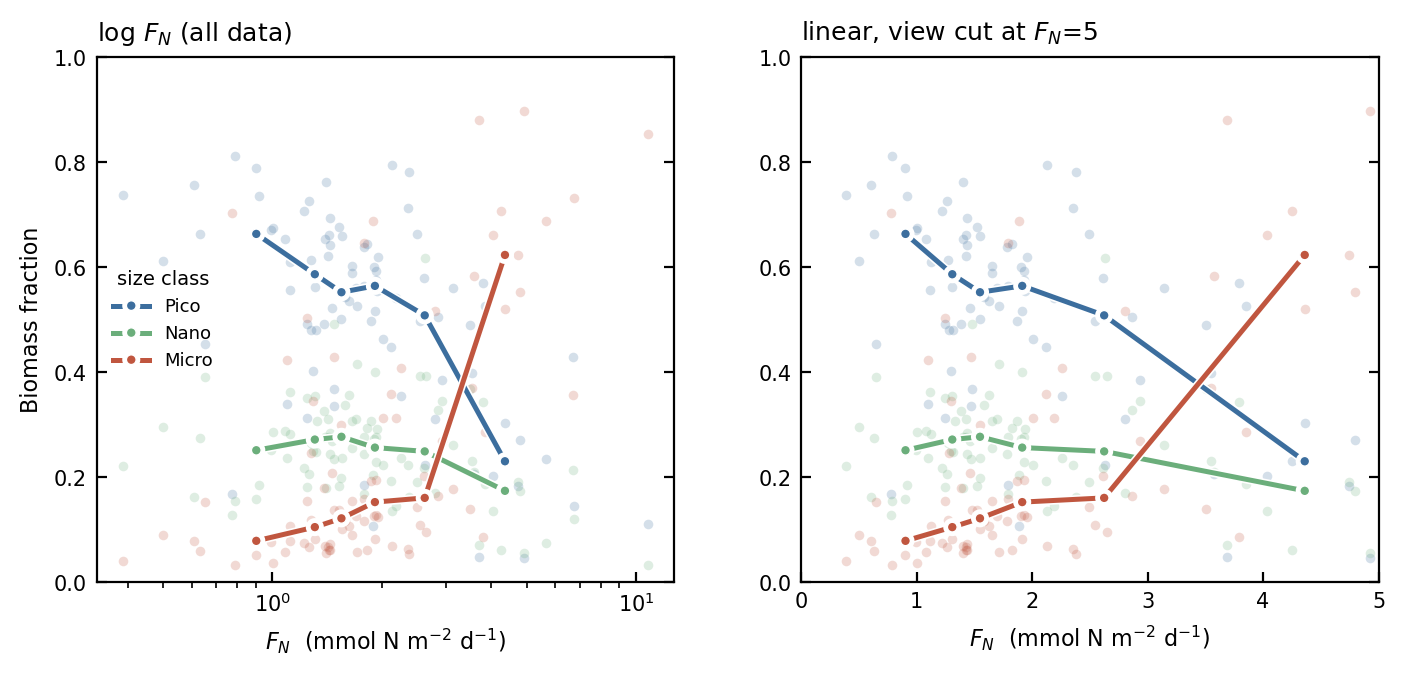

In [6]:
%config InlineBackend.figure_format = 'retina'
# Test — P/N/M fraction vs F_N:  LEFT log-x (all data)  |  RIGHT linear, view cut at F_N=5.
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.ticker import MaxNLocator
from cariaco_obs import DEFAULT_CSV_PATH

HALO = [pe.withStroke(linewidth=3.0, foreground='white')]
FNCOL = 'FN_mmolN_m2_d'
BINS = [('Pico', 'pico_mmolN', '#3C6E9E'),
        ('Nano', 'nano_mmolN', '#6BAE7B'),
        ('Micro', 'micro_mmolN', '#C0563F')]
cols = [c for _, c, _ in BINS]

df = pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date'])
d = df.dropna(subset=cols + [FNCOL]).copy()
tot = d[cols].sum(axis=1)
for name, c, _ in BINS:
    d[name + '_frac'] = d[c] / tot
d['fn_bin'] = pd.qcut(d[FNCOL], 6, duplicates='drop')
centers = d.groupby('fn_bin', observed=True)[FNCOL].median()
meds = {name: d.groupby('fn_bin', observed=True)[name + '_frac'].median() for name, _, _ in BINS}

fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.5))
fig.subplots_adjust(left=0.09, right=0.98, top=0.90, bottom=0.15, wspace=0.22)
for ax, mode in zip(axes, ['log', 'cut']):
    for name, c, col in BINS:
        ax.scatter(d[FNCOL], d[name + '_frac'], s=12, color=col, alpha=0.22, lw=0, zorder=2)
        ax.plot(centers.values, meds[name].values, color=col, lw=1.8, marker='o', ms=3.5,
                mec='white', mew=0.5, zorder=5, path_effects=HALO, label=name)
    ax.set_ylim(0, 1)
    ax.tick_params(top=False, right=True, direction='in', labelsize=7.5)
    ax.set_xlabel('$F_N$  (mmol N m$^{-2}$ d$^{-1}$)', fontsize=8)
    if mode == 'log':
        ax.set_xscale('log')
        ax.set_title('log $F_N$ (all data)', loc='left', fontsize=9)
        ax.set_ylabel('Biomass fraction', fontsize=8)
    else:
        ax.set_xlim(0, 5)
        ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
        ax.set_title('linear, view cut at $F_N$=5', loc='left', fontsize=9)
axes[0].legend(title='size class', frameon=False, fontsize=6.5, title_fontsize=7, loc='center left')
plt.show()

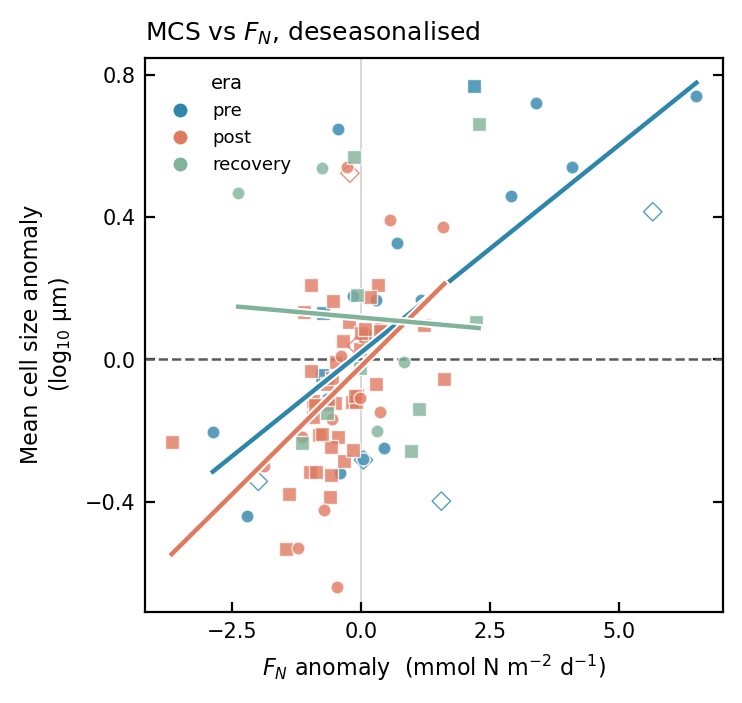

era          n mean_dMCS    slope     rho         p   (deseasonalised)
all         94   -0.0000   0.1151   0.497   3.4e-07
pre         23    0.1160   0.1169   0.625    0.0014
post        57   -0.0751   0.1441   0.583   1.9e-06
recovery    14    0.1150  -0.0129  -0.015      0.96


In [7]:
%config InlineBackend.figure_format = 'retina'
# Test — MCS vs F_N DESEASONALISED (both axes = anomaly vs pooled monthly climatology).
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D
from scipy.stats import spearmanr
from cariaco_obs import DEFAULT_CSV_PATH

ERA_COL = {'pre': '#2E86AB', 'post': '#E07A5F', 'recovery': '#81B29A'}
REG_MK  = {'upwelling': 'o', 'relaxed': 's', 'transition': 'D'}
HALO = [pe.withStroke(linewidth=3.0, foreground='white')]
FNCOL = 'FN_mmolN_m2_d'

df = pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date'])
df['mcs_log'] = df['size_centroid']                       # log10 MCS (µm)
df['era'] = np.where(df['date'].dt.year < 2005, 'pre',
            np.where(df['date'].dt.year < 2014, 'post', 'recovery'))
d = df.dropna(subset=['mcs_log', FNCOL]).copy()
d['mo'] = d['date'].dt.month
d['mcs_anom'] = d['mcs_log'] - d.groupby('mo')['mcs_log'].transform('mean')   # pooled climatology
d['fn_anom']  = d[FNCOL]     - d.groupby('mo')[FNCOL].transform('mean')
d['regime_adjusted'] = (d['regime_adjusted'].fillna('unknown')
                        if 'regime_adjusted' in d else 'unknown')

fig, ax = plt.subplots(figsize=(3.7, 3.6))
fig.subplots_adjust(left=0.18, right=0.96, top=0.92, bottom=0.15)
for e in ['pre', 'post', 'recovery']:
    s = d[d.era == e]
    for r, sr in s.groupby('regime_adjusted'):
        m = REG_MK.get(r, 'x')
        face = 'none' if r == 'transition' else ERA_COL[e]
        edge = ERA_COL[e] if r == 'transition' else 'white'
        ax.scatter(sr.fn_anom, sr.mcs_anom, marker=m, s=22, alpha=0.8,
                   facecolor=face, edgecolor=edge, linewidth=0.5, zorder=3)
    if len(s) >= 8:
        b = np.polyfit(s.fn_anom, s.mcs_anom, 1)
        xx = np.linspace(s.fn_anom.min(), s.fn_anom.max(), 50)
        ax.plot(xx, np.polyval(b, xx), color=ERA_COL[e], lw=1.6, zorder=5, path_effects=HALO)

ax.axhline(0, color='0.35', ls='--', lw=0.9, zorder=2)
ax.axvline(0, color='0.82', lw=0.6, zorder=1)
ax.xaxis.set_major_locator(MaxNLocator(nbins=5)); ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
ax.tick_params(top=False, right=True, direction='in', labelsize=7.5)
ax.set_ylabel('Mean cell size anomaly\n(log$_{10}$ µm)', fontsize=8)
ax.set_xlabel('$F_N$ anomaly  (mmol N m$^{-2}$ d$^{-1}$)', fontsize=8)
ax.set_title('MCS vs $F_N$, deseasonalised', loc='left', fontsize=9)
eh = [Line2D([0], [0], marker='o', color='w', markerfacecolor=ERA_COL[e], markersize=6, label=e)
      for e in ['pre', 'post', 'recovery']]
ax.legend(handles=eh, title='era', loc='upper left', frameon=False, fontsize=6.5, title_fontsize=7)
plt.show()

print(f"{'era':9s} {'n':>4s} {'mean_dMCS':>9s} {'slope':>8s} {'rho':>7s} {'p':>9s}   (deseasonalised)")
for e in ['all', 'pre', 'post', 'recovery']:
    s = d if e == 'all' else d[d.era == e]
    rho, p = spearmanr(s.fn_anom, s.mcs_anom)
    b = np.polyfit(s.fn_anom, s.mcs_anom, 1)
    print(f"{e:9s} {len(s):>4d} {s.mcs_anom.mean():>9.4f} {b[0]:>8.4f} {rho:>7.3f} {p:>9.2g}")

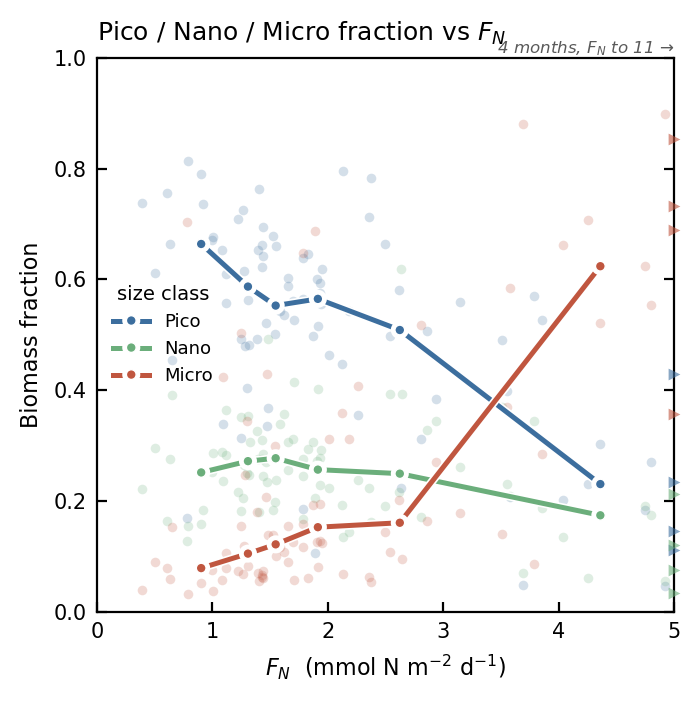

off-scale (F_N>5.0): n=4; median P/N/M = 0.19/0.10/0.71


In [8]:
%config InlineBackend.figure_format = 'retina'
# Fig 3 Panel 2 draft — P/N/M fraction vs F_N, linear view cut at F_N=5,
# off-scale months flagged as edge chevrons + a count annotation.
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.ticker import MaxNLocator
from cariaco_obs import DEFAULT_CSV_PATH

HALO = [pe.withStroke(linewidth=3.0, foreground='white')]
FNCOL = 'FN_mmolN_m2_d'
XCUT = 5.0
BINS = [('Pico', 'pico_mmolN', '#3C6E9E'),
        ('Nano', 'nano_mmolN', '#6BAE7B'),
        ('Micro', 'micro_mmolN', '#C0563F')]
cols = [c for _, c, _ in BINS]

df = pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date'])
d = df.dropna(subset=cols + [FNCOL]).copy()
tot = d[cols].sum(axis=1)
for name, c, _ in BINS:
    d[name + '_frac'] = d[c] / tot
d['fn_bin'] = pd.qcut(d[FNCOL], 6, duplicates='drop')
centers = d.groupby('fn_bin', observed=True)[FNCOL].median()
meds = {name: d.groupby('fn_bin', observed=True)[name + '_frac'].median() for name, _, _ in BINS}

inb, oob = d[d[FNCOL] <= XCUT], d[d[FNCOL] > XCUT]

fig, ax = plt.subplots(figsize=(3.7, 3.6))
fig.subplots_adjust(left=0.16, right=0.94, top=0.92, bottom=0.15)
for name, c, col in BINS:
    ax.scatter(inb[FNCOL], inb[name + '_frac'], s=12, color=col, alpha=0.22, lw=0, zorder=2)
    ax.scatter(np.full(len(oob), XCUT), oob[name + '_frac'], marker='>', s=18,
               color=col, alpha=0.6, lw=0, zorder=6, clip_on=False)          # off-scale flag
    ax.plot(centers.values, meds[name].values, color=col, lw=1.8, marker='o', ms=3.5,
            mec='white', mew=0.5, zorder=5, path_effects=HALO, label=name)

ax.set_xlim(0, XCUT); ax.set_ylim(0, 1)
ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
ax.tick_params(top=False, right=True, direction='in', labelsize=7.5)
ax.set_xlabel('$F_N$  (mmol N m$^{-2}$ d$^{-1}$)', fontsize=8)
ax.set_ylabel('Biomass fraction', fontsize=8)
ax.set_title('Pico / Nano / Micro fraction vs $F_N$', loc='left', fontsize=9)
ax.text(XCUT, 1.0, f' {len(oob)} months, $F_N$ to {d[FNCOL].max():.0f} →',
        ha='right', va='bottom', fontsize=6, color='0.35', style='italic')
ax.legend(title='size class', frameon=False, fontsize=6.5, title_fontsize=7, loc='center left')
plt.show()

print(f"off-scale (F_N>{XCUT}): n={len(oob)}; median P/N/M = "
      f"{oob['Pico_frac'].median():.2f}/{oob['Nano_frac'].median():.2f}/{oob['Micro_frac'].median():.2f}")

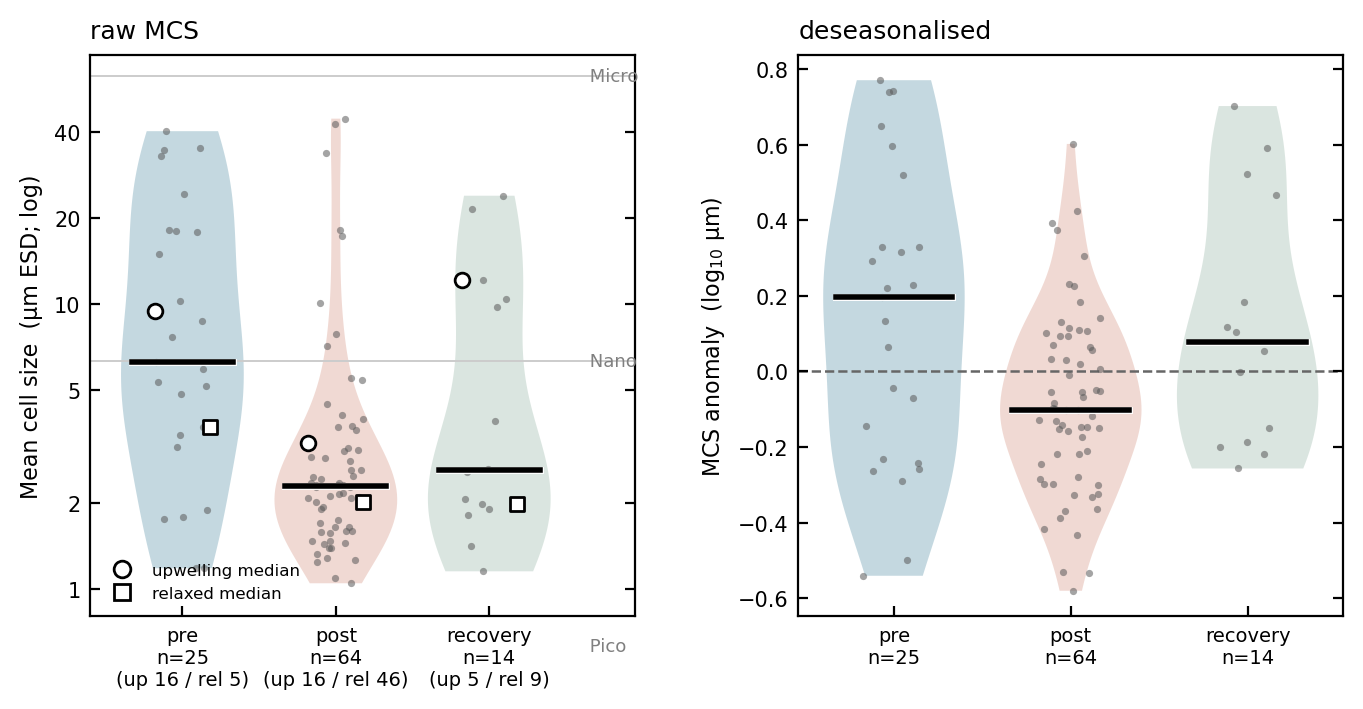

RAW (log10 µm; µm in parens):
  pre       n= 25  median=+0.796 (6.3 µm)  up=+0.975  rel=+0.569
  post      n= 64  median=+0.361 (2.3 µm)  up=+0.512  rel=+0.304
  recovery  n= 14  median=+0.416 (2.6 µm)  up=+1.082  rel=+0.297
DESEASONALISED (log10 µm anomaly):
  pre       n= 25  median=+0.196  mean=+0.142
  post      n= 64  median=-0.101  mean=-0.082
  recovery  n= 14  median=+0.079  mean=+0.123


In [9]:
%config InlineBackend.figure_format = 'retina'
# Fig 3 Panel 1 test — MCS era violin: LEFT raw µm (with regime split, option c) | RIGHT deseasonalised.
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
from cariaco_obs import DEFAULT_CSV_PATH

ERA_ORDER = ['pre', 'post', 'recovery']
ERA_COL = {'pre': '#2E86AB', 'post': '#E07A5F', 'recovery': '#81B29A'}
UM_TICKS = [1, 2, 5, 10, 20, 40]
GEOMEANS = {'Pico': 0.63, 'Nano': 6.3, 'Micro': 63.0}
HALO = [pe.withStroke(linewidth=2.5, foreground='white')]

df = pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date'])
df['era'] = np.where(df['date'].dt.year < 2005, 'pre',
            np.where(df['date'].dt.year < 2014, 'post', 'recovery'))
d = df.dropna(subset=['size_centroid']).copy()                 # centroid = log10 MCS (µm)
d['mo'] = d['date'].dt.month
d['mcs_anom'] = d['size_centroid'] - d.groupby('mo')['size_centroid'].transform('mean')
d['regime_adjusted'] = (d['regime_adjusted'].fillna('unknown')
                        if 'regime_adjusted' in d else 'unknown')

fig, (axR, axA) = plt.subplots(1, 2, figsize=(7.2, 3.9))
fig.subplots_adjust(left=0.10, right=0.97, top=0.90, bottom=0.18, wspace=0.30)

def soften_violins(ax):
    for v in ax.collections:
        v.set_alpha(0.30); v.set_edgecolor('none')

# ---------- LEFT: raw MCS (log10 µm), regime split ----------
sns.violinplot(data=d, x='era', y='size_centroid', order=ERA_ORDER, hue='era',
               palette=ERA_COL, legend=False, inner=None, cut=0, linewidth=0.8, ax=axR)
soften_violins(axR)
sns.stripplot(data=d, x='era', y='size_centroid', order=ERA_ORDER, color='0.35',
              size=2.6, alpha=0.55, jitter=0.18, ax=axR)
for i, e in enumerate(ERA_ORDER):
    s = d[d.era == e]
    axR.plot([i - 0.33, i + 0.33], [s.size_centroid.median()] * 2, color='black', lw=2.0,
             zorder=6, path_effects=HALO)
    for r, dx, mk in [('upwelling', -0.18, 'o'), ('relaxed', 0.18, 's')]:
        sr = s[s.regime_adjusted == r]
        if len(sr):
            axR.scatter(i + dx, sr.size_centroid.median(), marker=mk, s=28, facecolor='white',
                        edgecolor='black', linewidth=1.0, zorder=7)
for name, um in GEOMEANS.items():
    y = np.log10(um)
    axR.axhline(y, color='0.8', lw=0.7, zorder=1)
    axR.text(2.62, y, f' {name}', va='center', ha='left', fontsize=6.5, color='0.5')
axR.set_xlim(-0.6, 2.95)
axR.set_yticks([np.log10(u) for u in UM_TICKS]); axR.set_yticklabels(UM_TICKS)
axR.set_ylim(np.log10(0.8), np.log10(75))
axR.set_ylabel('Mean cell size  (µm ESD; log)', fontsize=8); axR.set_xlabel('')
axR.set_title('raw MCS', loc='left', fontsize=9)
axR.tick_params(top=False, right=True, direction='in', labelsize=7.5)
labs = []
for e in ERA_ORDER:
    s = d[d.era == e]
    nu = (s.regime_adjusted == 'upwelling').sum(); nr = (s.regime_adjusted == 'relaxed').sum()
    labs.append(f'{e}\nn={len(s)}\n(up {nu} / rel {nr})')
axR.set_xticks(range(3)); axR.set_xticklabels(labs, fontsize=7)
axR.legend(handles=[Line2D([0], [0], marker='o', color='w', markerfacecolor='white',
                    markeredgecolor='black', label='upwelling median', markersize=6),
                    Line2D([0], [0], marker='s', color='w', markerfacecolor='white',
                    markeredgecolor='black', label='relaxed median', markersize=6)],
           loc='lower left', frameon=False, fontsize=6)

# ---------- RIGHT: deseasonalised anomaly ----------
sns.violinplot(data=d, x='era', y='mcs_anom', order=ERA_ORDER, hue='era',
               palette=ERA_COL, legend=False, inner=None, cut=0, linewidth=0.8, ax=axA)
soften_violins(axA)
sns.stripplot(data=d, x='era', y='mcs_anom', order=ERA_ORDER, color='0.35',
              size=2.6, alpha=0.55, jitter=0.18, ax=axA)
for i, e in enumerate(ERA_ORDER):
    s = d[d.era == e]
    axA.plot([i - 0.33, i + 0.33], [s.mcs_anom.median()] * 2, color='black', lw=2.0,
             zorder=6, path_effects=HALO)
axA.axhline(0, color='0.4', ls='--', lw=0.9, zorder=1)
axA.set_ylabel('MCS anomaly  (log$_{10}$ µm)', fontsize=8); axA.set_xlabel('')
axA.set_title('deseasonalised', loc='left', fontsize=9)
axA.tick_params(top=False, right=True, direction='in', labelsize=7.5)
axA.set_xticks(range(3))
axA.set_xticklabels([f'{e}\nn={len(d[d.era == e])}' for e in ERA_ORDER], fontsize=7)
plt.show()

print("RAW (log10 µm; µm in parens):")
for e in ERA_ORDER:
    s = d[d.era == e]
    up = s[s.regime_adjusted == 'upwelling'].size_centroid.median()
    rel = s[s.regime_adjusted == 'relaxed'].size_centroid.median()
    print(f"  {e:9s} n={len(s):3d}  median={s.size_centroid.median():+.3f} "
          f"({10 ** s.size_centroid.median():.1f} µm)  up={up:+.3f}  rel={rel:+.3f}")
print("DESEASONALISED (log10 µm anomaly):")
for e in ERA_ORDER:
    s = d[d.era == e]
    print(f"  {e:9s} n={len(s):3d}  median={s.mcs_anom.median():+.3f}  mean={s.mcs_anom.mean():+.3f}")

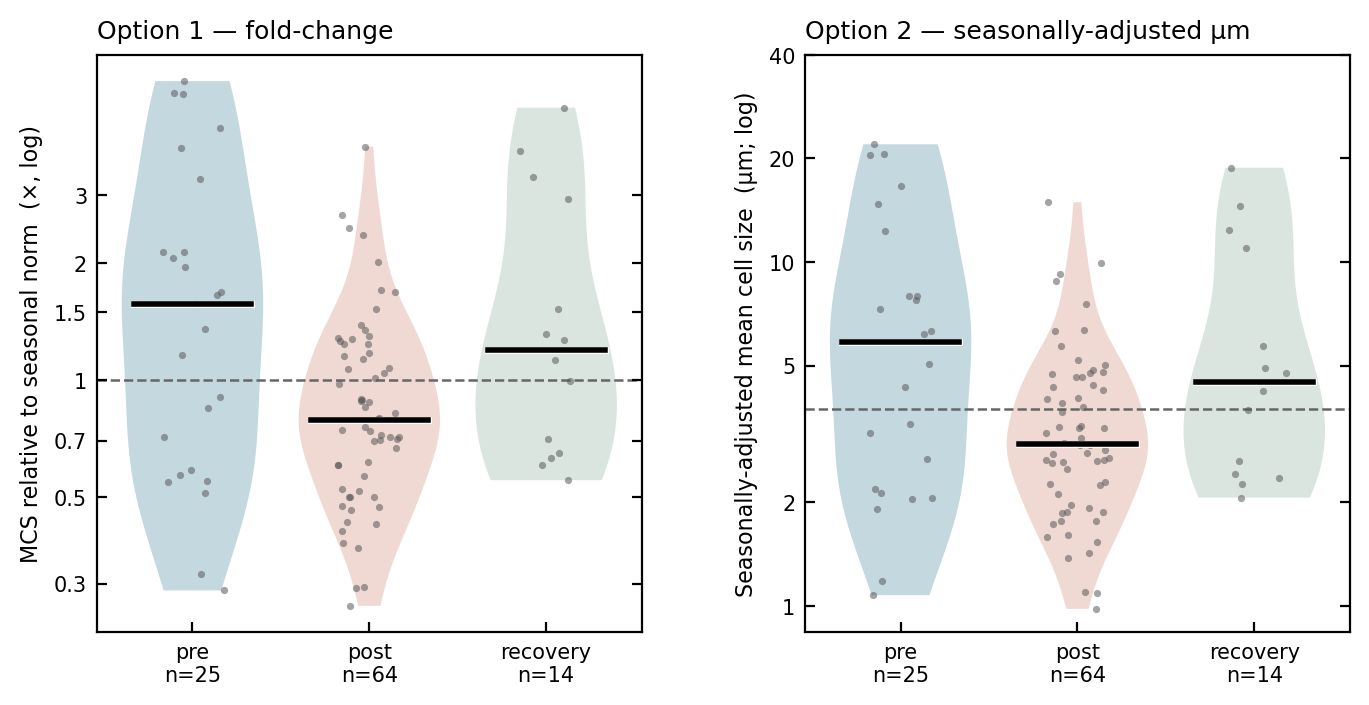

overall-mean MCS = 3.7 µm  (log10 +0.572)
  pre       fold-change=1.57x   adjusted=5.9 µm
  post      fold-change=0.79x   adjusted=3.0 µm
  recovery  fold-change=1.20x   adjusted=4.5 µm


In [10]:
%config InlineBackend.figure_format = 'retina'
# Deseasonalised MCS violin — two readable y-axes: LEFT fold-change (×) | RIGHT seasonally-adjusted µm.
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patheffects as pe
from cariaco_obs import DEFAULT_CSV_PATH

ERA_ORDER = ['pre', 'post', 'recovery']
ERA_COL = {'pre': '#2E86AB', 'post': '#E07A5F', 'recovery': '#81B29A'}
RATIO_TICKS = [0.3, 0.5, 0.7, 1, 1.5, 2, 3]
UM_TICKS = [1, 2, 5, 10, 20, 40]
HALO = [pe.withStroke(linewidth=2.5, foreground='white')]

df = pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date'])
df['era'] = np.where(df['date'].dt.year < 2005, 'pre',
            np.where(df['date'].dt.year < 2014, 'post', 'recovery'))
d = df.dropna(subset=['size_centroid']).copy()                  # log10 MCS (µm)
d['mo'] = d['date'].dt.month
d['mcs_anom'] = d['size_centroid'] - d.groupby('mo')['size_centroid'].transform('mean')
GM = d['size_centroid'].mean()                                  # overall-mean log10 MCS
d['mcs_adj'] = d['mcs_anom'] + GM                               # seasonally-adjusted log10 µm

def soften(ax):
    for v in ax.collections:
        v.set_alpha(0.30); v.set_edgecolor('none')

def violin(ax, ycol, title):
    sns.violinplot(data=d, x='era', y=ycol, order=ERA_ORDER, hue='era',
                   palette=ERA_COL, legend=False, inner=None, cut=0, linewidth=0.8, ax=ax)
    soften(ax)
    sns.stripplot(data=d, x='era', y=ycol, order=ERA_ORDER, color='0.35',
                  size=2.6, alpha=0.55, jitter=0.18, ax=ax)
    for i, e in enumerate(ERA_ORDER):
        s = d[d.era == e]
        ax.plot([i - 0.33, i + 0.33], [s[ycol].median()] * 2, color='black', lw=2.0,
                zorder=6, path_effects=HALO)
    ax.set_xticks(range(3))
    ax.set_xticklabels([f'{e}\nn={len(d[d.era == e])}' for e in ERA_ORDER], fontsize=7.5)
    ax.set_xlabel(''); ax.set_title(title, loc='left', fontsize=9)
    ax.tick_params(top=False, right=True, direction='in', labelsize=7.5)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.2, 3.9))
fig.subplots_adjust(left=0.10, right=0.97, top=0.90, bottom=0.16, wspace=0.30)

violin(ax1, 'mcs_anom', 'Option 1 — fold-change')
ax1.axhline(0, color='0.4', ls='--', lw=0.9, zorder=1)         # 1.0x baseline
ax1.set_yticks([np.log10(r) for r in RATIO_TICKS]); ax1.set_yticklabels(RATIO_TICKS)
ax1.set_ylabel('MCS relative to seasonal norm  (×, log)', fontsize=8)

violin(ax2, 'mcs_adj', 'Option 2 — seasonally-adjusted µm')
ax2.axhline(GM, color='0.4', ls='--', lw=0.9, zorder=1)        # overall-mean baseline
ax2.set_yticks([np.log10(u) for u in UM_TICKS]); ax2.set_yticklabels(UM_TICKS)
ax2.set_ylabel('Seasonally-adjusted mean cell size  (µm; log)', fontsize=8)

plt.show()

print(f"overall-mean MCS = {10 ** GM:.1f} µm  (log10 {GM:+.3f})")
for e in ERA_ORDER:
    a = d[d.era == e]['mcs_anom'].median()
    print(f"  {e:9s} fold-change={10 ** a:.2f}x   adjusted={10 ** (a + GM):.1f} µm")

In [11]:
# Era-contrast statistics for the MCS violin (printout only; for methods / rebuttal).
import numpy as np, pandas as pd
from scipy.stats import kruskal, mannwhitneyu
from cariaco_obs import DEFAULT_CSV_PATH

ERA_ORDER = ['pre', 'post', 'recovery']
df = pd.read_csv(DEFAULT_CSV_PATH, parse_dates=['date'])
df['era'] = np.where(df['date'].dt.year < 2005, 'pre',
            np.where(df['date'].dt.year < 2014, 'post', 'recovery'))
d = df.dropna(subset=['size_centroid']).copy()
d['mo'] = d['date'].dt.month
d['mcs_anom'] = d['size_centroid'] - d.groupby('mo')['size_centroid'].transform('mean')

def cliffs_delta(x, y):
    x, y = np.asarray(x), np.asarray(y)
    return np.sign(x[:, None] - y[None, :]).mean()          # + => first group larger

def holm(pvals):
    pvals = np.asarray(pvals); m = len(pvals); order = np.argsort(pvals)
    adj = np.empty(m); run = 0.0
    for rank, idx in enumerate(order):
        run = max(run, (m - rank) * pvals[idx]); adj[idx] = min(run, 1.0)
    return adj

def boot_fold_ci(a, b, n=5000, seed=0):
    rng = np.random.default_rng(seed); a, b = np.asarray(a), np.asarray(b)
    diffs = [np.median(rng.choice(a, a.size)) - np.median(rng.choice(b, b.size)) for _ in range(n)]
    lo, hi = np.percentile(diffs, [2.5, 97.5])
    return 10 ** lo, 10 ** hi

PAIRS = [('pre', 'post'), ('pre', 'recovery'), ('post', 'recovery')]

def run_block(col, label):
    groups = [d.loc[d.era == e, col].values for e in ERA_ORDER]
    H, pk = kruskal(*groups)
    print(f"\n=== {label} ===")
    print(f"Kruskal-Wallis (3 eras): H={H:.2f}  p={pk:.2g}")
    praw = [mannwhitneyu(d.loc[d.era == a, col], d.loc[d.era == b, col],
                         alternative='two-sided')[1] for a, b in PAIRS]
    pholm = holm(praw)
    print(f"{'pair':15s} {'n1,n2':>8s} {'p_raw':>8s} {'p_holm':>8s} {'Cliff_d':>8s} {'fold(med)':>10s} {'95% CI':>15s}")
    for (a, b), pr, ph in zip(PAIRS, praw, pholm):
        x, y = d.loc[d.era == a, col].values, d.loc[d.era == b, col].values
        dlt = cliffs_delta(x, y)
        fold = 10 ** (np.median(x) - np.median(y)); lo, hi = boot_fold_ci(x, y)
        print(f"{a+' vs '+b:15s} {f'{len(x)},{len(y)}':>8s} {pr:>8.2g} {ph:>8.2g} "
              f"{dlt:>+8.2f} {fold:>9.2f}x [{lo:.2f}, {hi:.2f}]")

run_block('mcs_anom', 'MONTHLY - deseasonalised MCS anomaly')
run_block('size_centroid', 'MONTHLY - raw MCS (log10 um)')

print("\n=== ANNUAL-MEAN robustness (more independent samples) ===")
for col, lab in [('mcs_anom', 'deseasonalised'), ('size_centroid', 'raw')]:
    ann = d.assign(yr=d.date.dt.year).groupby('yr').agg(val=(col, 'mean')).reset_index()
    ann['era'] = np.where(ann.yr < 2005, 'pre', np.where(ann.yr < 2014, 'post', 'recovery'))
    g = [ann.loc[ann.era == e, 'val'].values for e in ERA_ORDER]
    H, pk = kruskal(*g)
    pp = mannwhitneyu(g[0], g[1], alternative='two-sided')[1]
    print(f"  {lab:14s} years pre/post/rec = {len(g[0])}/{len(g[1])}/{len(g[2])}  "
          f"KW p={pk:.2g}  pre-vs-post MW p={pp:.2g}")

print("\nNote: monthly values are temporally autocorrelated -> p-values are optimistic; "
      "weight the Cliff's delta + bootstrap fold-change CIs. The annual-mean block is the "
      "independence cross-check (recovery years are few).")


=== MONTHLY - deseasonalised MCS anomaly ===
Kruskal-Wallis (3 eras): H=8.56  p=0.014
pair               n1,n2    p_raw   p_holm  Cliff_d  fold(med)          95% CI
pre vs post        25,64    0.011    0.032    +0.35      1.98x [0.92, 2.72]
pre vs recovery    25,14     0.85     0.85    +0.04      1.31x [0.51, 2.55]
post vs recovery    64,14    0.052      0.1    -0.33      0.66x [0.34, 1.21]

=== MONTHLY - raw MCS (log10 um) ===
Kruskal-Wallis (3 eras): H=13.49  p=0.0012
pair               n1,n2    p_raw   p_holm  Cliff_d  fold(med)          95% CI
pre vs post        25,64  0.00021  0.00064    +0.51      2.72x [1.72, 7.65]
pre vs recovery    25,14     0.16     0.31    +0.28      2.40x [0.55, 6.77]
post vs recovery    64,14      0.3     0.31    -0.18      0.88x [0.21, 1.22]

=== ANNUAL-MEAN robustness (more independent samples) ===
  deseasonalised years pre/post/rec = 5/7/3  KW p=0.067  pre-vs-post MW p=0.15
  raw            years pre/post/rec = 5/7/3  KW p=0.0035  pre-vs-post MW p=0.0